### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Часть 1: Классификация ирисов Фишера с помощью метода kNN

### Загрузка данных

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

### Преобразование данных

In [3]:
df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
df['species_name'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df['species'] = iris.target
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species_name,species
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


### Описание данных

In [4]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
print(f'Null values: {df.isnull().sum()}')

Null values: sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species_name    0
species         0
dtype: int64


In [6]:
print(f'values counts: {df["species"].value_counts()}')

values counts: species
0    50
1    50
2    50
Name: count, dtype: int64


### Визуализация данных

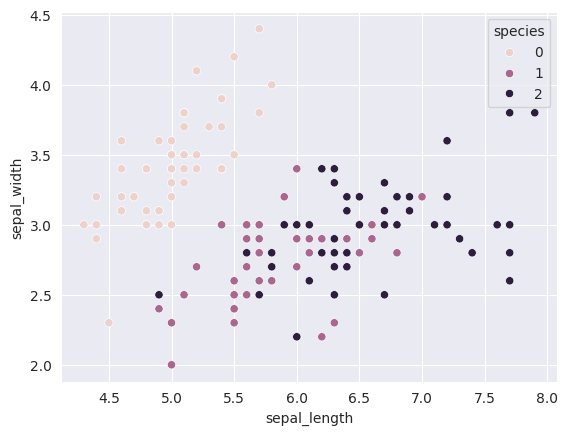

In [7]:
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species')
plt.show()

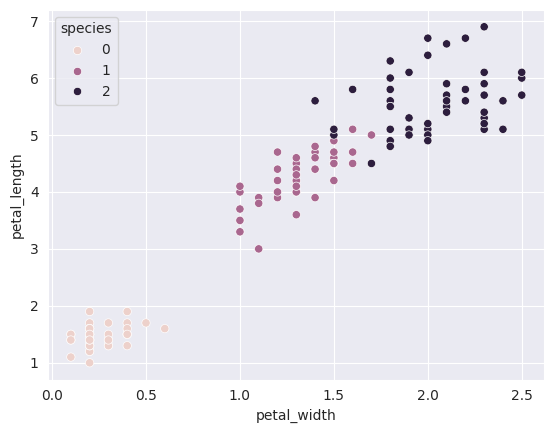

In [8]:
sns.scatterplot(data=df, x='petal_width', y='petal_length', hue='species')
plt.show()

### Создание массивов X и y входных данных и меток классов

In [9]:
X = iris.data
y = iris.target
dataset = X[:150:15]
output = y[:150:15]

### Функция, вычисляющая евклидово расстояние между двумя векторами `row1` и `row2`

In [10]:
def euclidean_distance(row1, row2):
    return np.sqrt(np.sum((row1 - row2) ** 2, axis=1))

print(euclidean_distance(dataset, dataset[5]))

[3.59722115 3.48998567 3.539774   3.66742416 2.12837967 0.
 1.18743421 2.51594913 1.62172747 2.21585198]


### Функция, находящая в `train_set` выборке `k = num_neighbors` ближайших соседей (евклидово расстояние) к данному `test_row`

In [11]:
def get_neighbors(train_set, labels, test_row, num_neighbors):
    distances = euclidean_distance(train_set, test_row)
    k_nearest_indexes = np.argsort(distances)[:num_neighbors]
    values = train_set[k_nearest_indexes]
    targets = labels[k_nearest_indexes]
    result = list()
    for i in range(num_neighbors):
        result.append((values[i], distances[i], targets[i]))
    return result

neighbors = get_neighbors(dataset, output, dataset[5], 3)
neighbors

[(array([6.6, 3. , 4.4, 1.4]), np.float64(3.59722114972099), np.int64(1)),
 (array([5.5, 2.6, 4.4, 1.2]), np.float64(3.4899856733230297), np.int64(1)),
 (array([6.9, 3.2, 5.7, 2.3]), np.float64(3.539774004085572), np.int64(2))]

### Функция, возвращающая метку класса, к которому вероятно принадлежит объект `test_row`

In [12]:
def predict_classification(train_set, labels, test_row, num_neighbors):
    neighbors = get_neighbors(train_set, labels, test_row, num_neighbors)
    output_values = [row[-1] for row in neighbors]
    prediction = max(set(output_values), key=output_values.count)
    return prediction

prediction = predict_classification(dataset, output, dataset[5], 3)
print('Expected %d, Got %d.' % (output[5], prediction))

Expected 1, Got 1.


### Функция kNN, которая получает на вход набор элементов, для каждого из них определяет класс и возвращает список предсказанных ответов

In [13]:
def k_nearest_neighbors(train_set, labels, test, num_neighbors):
    predictions = list()
    for row in test:
        output = predict_classification(train_set, labels, row, num_neighbors)
        predictions.append(output)
    return predictions

### Разбиваем выборку на обучающую и тестовую

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Находим долю правильных ответов для нашего kNN классификатора

In [15]:
predictions = k_nearest_neighbors(X_train, y_train, X_test, 5)
print(f'Accuracy: {np.sum(y_test == predictions) / len(y_test):.2f}')

Accuracy: 1.00


### Визуализируем матрицу ошибок для нашего kNN классификатора

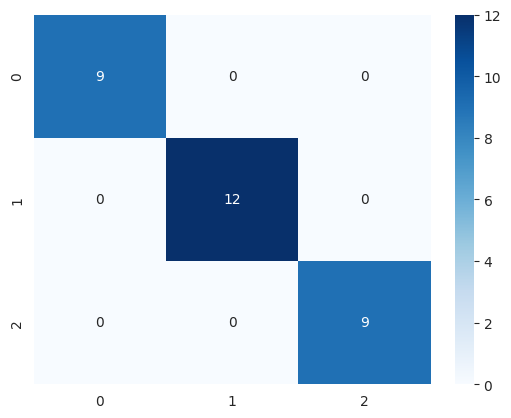

In [16]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.show()

### Находим долю правильных ответов для нашего kNN классификатора при другом разбиении выборки

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
predictions = k_nearest_neighbors(X_train, y_train, X_test, 3)
print(f'Accuracy: {np.sum(y_test == predictions) / len(y_test):.2f}')

Accuracy: 0.97


### Визуализируем матрицу ошибок для нашего kNN классификатора при другом разбиении выборки

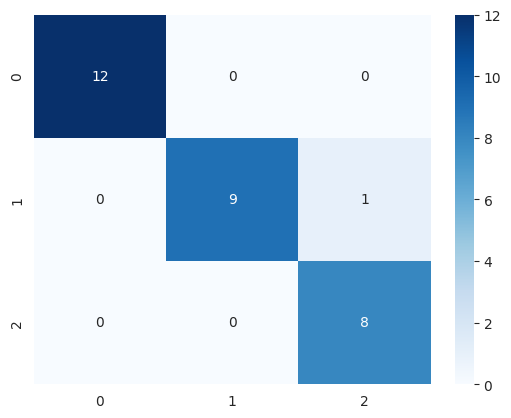

In [18]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.show()

### Проверим насколько сильно точность классификатора зависит от удачи в разбиении выборки

In [19]:
train_test_split_bench_data = []

def train_test_split_bench():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    predictions = k_nearest_neighbors(X_train, y_train, X_test, 3)
    accuracy = np.sum(y_test == predictions) / len(y_test)
    train_test_split_bench_data.append([accuracy])

for i in range(1000):
    train_test_split_bench()

train_test_split_bench_dataframe = pd.DataFrame(train_test_split_bench_data, columns=['accuracy'])
train_test_split_bench_dataframe.describe()

,accuracy
count,1000.000000
mean,0.960600
std,0.029771
min,0.866667
25%,0.933333
50%,0.966667
75%,0.966667
max,1.000000


### Визуализируем данные

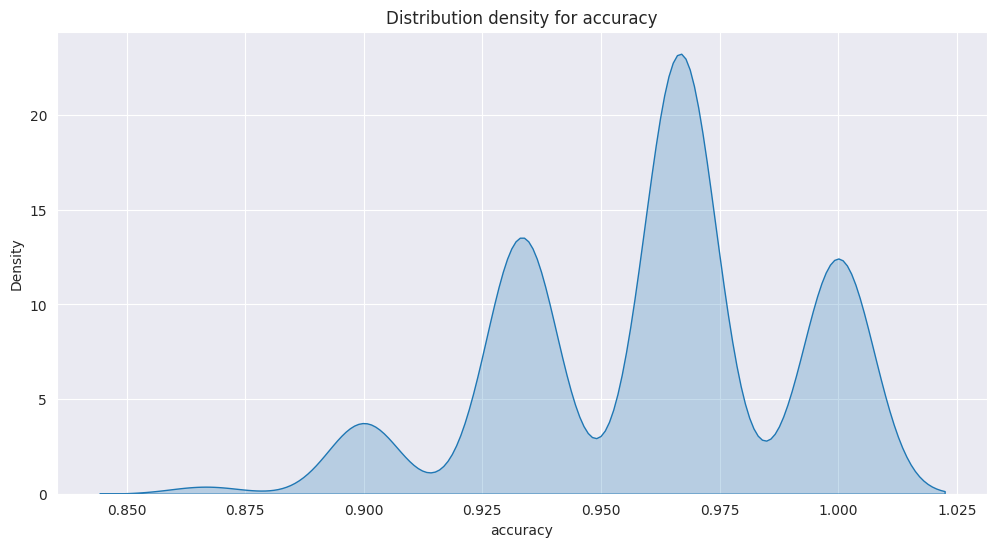

In [20]:
plt.figure(figsize=(12, 6))
sns.kdeplot(
    data=train_test_split_bench_dataframe,
    x="accuracy",
    fill=True,
)
plt.title("Distribution density for accuracy")
plt.show()

### Для выбора оптимального значения k построим график зависимости точности классификатора от числа k=1,.., 60. Посмотрите на этот график при различных разбиениях на тестовую и обучающую выборку

In [21]:
train_test_split_bench_data = []

def train_test_split_bench(k: int):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    predictions = k_nearest_neighbors(X_train, y_train, X_test, k)
    accuracy = np.sum(y_test == predictions) / len(y_test)
    train_test_split_bench_data.append([k, accuracy])

for k in range(1, 61):
    print(f'Started measuring k={k}')
    for i in range(1000):
        train_test_split_bench(k)

train_test_split_bench_dataframe = pd.DataFrame(train_test_split_bench_data, columns=['k', 'accuracy'])
train_test_split_bench_dataframe.describe()

Started measuring k=1
Started measuring k=2
Started measuring k=3
Started measuring k=4
Started measuring k=5
Started measuring k=6
Started measuring k=7
Started measuring k=8
Started measuring k=9
Started measuring k=10
Started measuring k=11
Started measuring k=12
Started measuring k=13
Started measuring k=14
Started measuring k=15
Started measuring k=16
Started measuring k=17
Started measuring k=18
Started measuring k=19
Started measuring k=20
Started measuring k=21
Started measuring k=22
Started measuring k=23
Started measuring k=24
Started measuring k=25
Started measuring k=26
Started measuring k=27
Started measuring k=28
Started measuring k=29
Started measuring k=30
Started measuring k=31
Started measuring k=32
Started measuring k=33
Started measuring k=34
Started measuring k=35
Started measuring k=36
Started measuring k=37
Started measuring k=38
Started measuring k=39
Started measuring k=40
Started measuring k=41
Started measuring k=42
Started measuring k=43
Started measuring k=

,k,accuracy
count,60000.000000,60000.000000
mean,30.500000,0.939323
std,17.318247,0.048044
min,1.000000,0.566667
25%,15.750000,0.900000
50%,30.500000,0.933333
75%,45.250000,0.966667
max,60.000000,1.000000


### Визуализация данных

/tmp/ipykernel_46570/621684991.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("k_bin")["accuracy"]


<Axes: xlabel='k_bin', ylabel='mean_accuracy'>

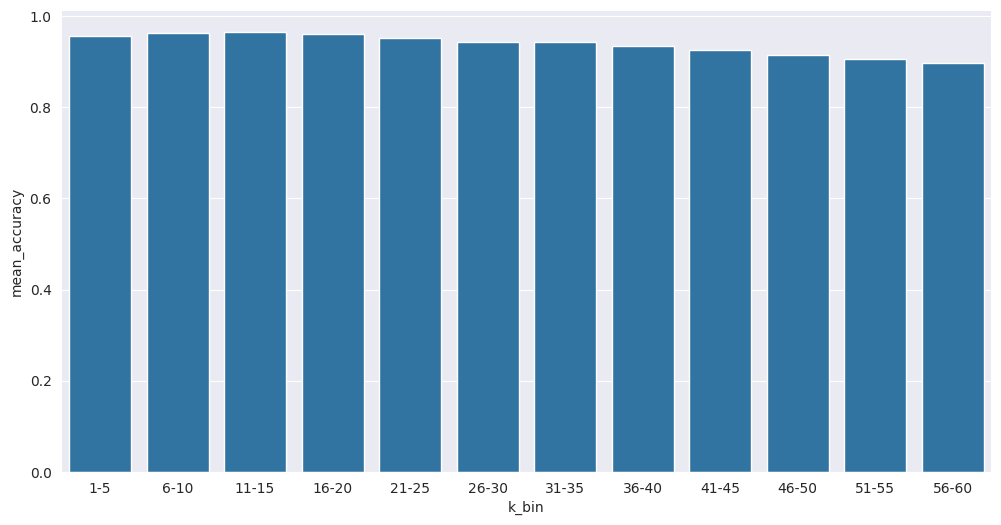

In [22]:
train_test_split_bench_dataframe["k_bin"] = pd.cut(
    train_test_split_bench_dataframe["k"],
    bins=12,
    labels=[f"{i*5+1}-{(i+1)*5}" for i in range(12)]
)

grouped = (
    train_test_split_bench_dataframe
    .groupby("k_bin")["accuracy"]
    .mean()
    .reset_index(name="mean_accuracy")
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=grouped,
    x="k_bin",
    y="mean_accuracy"
)

### Сравниваем точность работы `KNeighborsClassifier` и `LogisticRegression` из `sklearn` и нашего kNN классификатора

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [24]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
knn_predictions = knn.predict(X_test)

lr = LogisticRegression(random_state=2025)
lr.fit(X_train, y_train)
lr_predictions = lr.predict(X_test)

print(f'Sklearn KNN Accuracy: {np.sum(y_test == knn_predictions) / len(y_test):.2f}')
print(f'Logistic Regression Accuracy: {np.sum(y_test == lr_predictions) / len(y_test):.2f}')
print(f'Our model Accuracy: {np.sum(y_test == k_nearest_neighbors(X_train, y_train, X_test, 3)) / len(y_test):.2f}')

Sklearn KNN Accuracy: 0.93
Logistic Regression Accuracy: 0.97
Our model Accuracy: 0.93
